In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/Dataset.zip" -d "/content/dataset"

Archive:  /content/drive/MyDrive/Dataset.zip
   creating: /content/dataset/raw/
   creating: /content/dataset/raw/ahmed_sharif_chaudhry/
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000001.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000002.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000003.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000004.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000005.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000006.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000007.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000008.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000009.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000010.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000011.jpg  
  inflating: /content/dataset/raw/ahmed_sharif_chaudhry/000012.jpg  
  inflating: /content/dataset/raw/a

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

In [4]:
import os

BASE = "/content/dataset"

print("Dataset Files/Folders:")
print(os.listdir(BASE))

dataset_folder = os.listdir(BASE)[0]

print("\nInside Dataset Folder:")
print(os.listdir(f"{BASE}/{dataset_folder}"))

Dataset Files/Folders:
['raw']

Inside Dataset Folder:
['shahbaz_sharif', 'bilawal_bhutto', 'asif_ali_zardari', 'barrister_gohar', 'imran_khan', 'pervez_musharraf', 'maryam_nawaz', 'ahsan_iqbal', 'nawaz_sharif', 'fazlur_rehman', 'khawaja_asif', 'chaudhry_shujaat', 'shehryar_afridi', 'altaf_hussain', 'asfandyar_wali', 'ahmed_sharif_chaudhry']


In [5]:
ROOT = BASE

for item in os.listdir(ROOT):
    path = os.path.join(ROOT, item)

    print("\n", item)

    if os.path.isdir(path):
        print(os.listdir(path))


 raw
['shahbaz_sharif', 'bilawal_bhutto', 'asif_ali_zardari', 'barrister_gohar', 'imran_khan', 'pervez_musharraf', 'maryam_nawaz', 'ahsan_iqbal', 'nawaz_sharif', 'fazlur_rehman', 'khawaja_asif', 'chaudhry_shujaat', 'shehryar_afridi', 'altaf_hussain', 'asfandyar_wali', 'ahmed_sharif_chaudhry']


In [6]:
DATA_DIR = "/content/dataset"

In [7]:
import os

print(os.listdir("/content/dataset"))

['raw']


In [10]:
import os

DATA_DIR = "/content/dataset/raw"

classes = os.listdir(DATA_DIR)

print(f"Total Classes: {len(classes)}")

print("\nClasses:\n")

for cls in classes:
    print(cls)

Total Classes: 16

Classes:

shahbaz_sharif
bilawal_bhutto
asif_ali_zardari
barrister_gohar
imran_khan
pervez_musharraf
maryam_nawaz
ahsan_iqbal
nawaz_sharif
fazlur_rehman
khawaja_asif
chaudhry_shujaat
shehryar_afridi
altaf_hussain
asfandyar_wali
ahmed_sharif_chaudhry


In [12]:
!pip install split-folders

In [13]:
import splitfolders

input_folder = "/content/dataset/raw"

output_folder = "/content/dataset"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.75, 0.15, 0.10)
)

print("Dataset Split Completed!")

Copying files: 1583 files [00:01, 1530.23 files/s]

Dataset Split Completed!


In [14]:
# ── Cell 3: Data Loading with Augmentation + JFIF Support ─────────────

import torch
from torchvision import datasets, transforms
from PIL import Image

# Updated Dataset Path
DATA_DIR = "/content/dataset"

# Custom Image Loader
def pil_loader(path):

    with open(path, 'rb') as f:

        img = Image.open(f)

        return img.convert('RGB')

# ── Train Transform ───────────────────────────────────────────────

train_transform = transforms.Compose([

    transforms.RandomRotation(15),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(brightness=0.3),

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ── Validation/Test Transform ─────────────────────────────────────

val_test_transform = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ── Supported Extensions ──────────────────────────────────────────

IMG_EXTENSIONS = (
    '.jpg',
    '.jpeg',
    '.png',
    '.bmp',
    '.jfif'
)

# ── Train Dataset ─────────────────────────────────────────────────

train_ds = datasets.ImageFolder(

    root=f"{DATA_DIR}/train",

    transform=train_transform,

    loader=pil_loader,

    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

# ── Validation Dataset ────────────────────────────────────────────

val_ds = datasets.ImageFolder(

    root=f"{DATA_DIR}/val",

    transform=val_test_transform,

    loader=pil_loader,

    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

# ── Test Dataset ──────────────────────────────────────────────────

test_ds = datasets.ImageFolder(

    root=f"{DATA_DIR}/test",

    transform=val_test_transform,

    loader=pil_loader,

    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

# ── Print Dataset Information ─────────────────────────────────────

print("Train Images      :", len(train_ds))

print("Validation Images :", len(val_ds))

print("Test Images       :", len(test_ds))

print("\nClasses:\n")

print(train_ds.classes)

Train Images      : 1181
Validation Images : 231
Test Images       : 171

Classes:

['ahmed_sharif_chaudhry', 'ahsan_iqbal', 'altaf_hussain', 'asfandyar_wali', 'asif_ali_zardari', 'barrister_gohar', 'bilawal_bhutto', 'chaudhry_shujaat', 'fazlur_rehman', 'imran_khan', 'khawaja_asif', 'maryam_nawaz', 'nawaz_sharif', 'pervez_musharraf', 'shahbaz_sharif', 'shehryar_afridi']


In [15]:
# ── Cell 4: Model (ResNet-50) ────────────────────────

import torch
import torch.nn as nn
import torchvision.models as models

# Load Pretrained ResNet50
model = models.resnet50(weights="IMAGENET1K_V1")

# Change Final Layer for 18 Classes
model.fc = nn.Linear(model.fc.in_features, 18)

# Move Model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)
print("\nUsing Device:", device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
# ── Cell 5: Device, Loss Function, Optimizer ────────────────────────

import torch
import torch.optim as optim
import torch.nn as nn

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# Move model to GPU/CPU
model = model.to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using Device: cuda


In [17]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [18]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image

# Updated Dataset Path
DATA_DIR = "/content/dataset"

train_dir = f"{DATA_DIR}/train"
val_dir   = f"{DATA_DIR}/val"
test_dir  = f"{DATA_DIR}/test"

# ── Custom Loader for JFIF Support ───────────────────────────────

def pil_loader(path):

    with open(path, 'rb') as f:

        img = Image.open(f)

        return img.convert('RGB')

# ── Supported Extensions ─────────────────────────────────────────

IMG_EXTENSIONS = (
    '.jpg',
    '.jpeg',
    '.png',
    '.bmp',
    '.jfif'
)

# ── Image Transformations ────────────────────────────────────────

transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor()
])

# ── Train Dataset ────────────────────────────────────────────────

train_dataset = datasets.ImageFolder(

    train_dir,

    transform=transform,

    loader=pil_loader,

    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

# ── Validation Dataset ───────────────────────────────────────────

val_dataset = datasets.ImageFolder(

    val_dir,

    transform=transform,

    loader=pil_loader,

    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

# ── Test Dataset ─────────────────────────────────────────────────

test_dataset = datasets.ImageFolder(

    test_dir,

    transform=transform,

    loader=pil_loader,

    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

# ── DataLoaders ──────────────────────────────────────────────────

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# ── Dataset Information ──────────────────────────────────────────

print("Train Images      :", len(train_dataset))

print("Validation Images :", len(val_dataset))

print("Test Images       :", len(test_dataset))

print("\nClasses:\n")

print(train_dataset.classes)

Train Images      : 1181
Validation Images : 231
Test Images       : 171

Classes:

['ahmed_sharif_chaudhry', 'ahsan_iqbal', 'altaf_hussain', 'asfandyar_wali', 'asif_ali_zardari', 'barrister_gohar', 'bilawal_bhutto', 'chaudhry_shujaat', 'fazlur_rehman', 'imran_khan', 'khawaja_asif', 'maryam_nawaz', 'nawaz_sharif', 'pervez_musharraf', 'shahbaz_sharif', 'shehryar_afridi']


In [19]:
import torch
from sklearn.metrics import classification_report

# Number of Epochs
num_epochs = 20

for epoch in range(num_epochs):

    # ── Training ─────────────────────────────
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        # Move to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        # Zero Gradients
        optimizer.zero_grad()

        # Forward Pass
        outputs = model(images)

        # Calculate Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update Weights
        optimizer.step()

        # Training Loss
        running_train_loss += loss.item()

        # Training Accuracy
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = train_correct / train_total
    train_loss = running_train_loss / len(train_loader)

    # ── Validation ───────────────────────────
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total
    val_loss = running_val_loss / len(val_loader)

    # ── Print Results ────────────────────────
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    print(f"Train Loss          : {train_loss:.4f}")
    print(f"Train Accuracy      : {train_acc:.4f}")

    print(f"Validation Loss     : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")

# ── Final Test Evaluation ─────────────────────

model.eval()

all_preds = []
all_labels = []

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Final Test Accuracy
test_acc = test_correct / test_total

print("\n===================================")
print(f"FINAL TEST ACCURACY : {test_acc:.4f}")
print("===================================")

# ── Classification Report ────────────────────
print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))


Epoch [1/20]
Train Loss          : 2.4871
Train Accuracy      : 0.2218
Validation Loss     : 9.7060
Validation Accuracy : 0.1558

Epoch [2/20]
Train Loss          : 1.9320
Train Accuracy      : 0.3709
Validation Loss     : 4.0313
Validation Accuracy : 0.2338

Epoch [3/20]
Train Loss          : 1.6133
Train Accuracy      : 0.4962
Validation Loss     : 2.1421
Validation Accuracy : 0.3463

Epoch [4/20]
Train Loss          : 1.2571
Train Accuracy      : 0.6207
Validation Loss     : 9.4531
Validation Accuracy : 0.2078

Epoch [5/20]
Train Loss          : 1.0541
Train Accuracy      : 0.6579
Validation Loss     : 1.8147
Validation Accuracy : 0.4372

Epoch [6/20]
Train Loss          : 0.8250
Train Accuracy      : 0.7324
Validation Loss     : 2.3667
Validation Accuracy : 0.3810

Epoch [7/20]
Train Loss          : 0.6647
Train Accuracy      : 0.7824
Validation Loss     : 2.0699
Validation Accuracy : 0.4805

Epoch [8/20]
Train Loss          : 0.4195
Train Accuracy      : 0.8764
Validation Loss   

In [20]:
# ── ResNet50 Transfer Learning Training on Google Colab ──────────────────

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report
from PIL import Image

# ──────────────────────────────────────────────────────────────────────────
# Device
# ──────────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ──────────────────────────────────────────────────────────────────────────
# Dataset Path
# ──────────────────────────────────────────────────────────────────────────

DATA_DIR = "/content/dataset"

train_dir = f"{DATA_DIR}/train"
val_dir   = f"{DATA_DIR}/val"
test_dir  = f"{DATA_DIR}/test"

# ──────────────────────────────────────────────────────────────────────────
# Custom Loader
# ──────────────────────────────────────────────────────────────────────────

def pil_loader(path):

    with open(path, 'rb') as f:

        img = Image.open(f)

        return img.convert('RGB')

# ──────────────────────────────────────────────────────────────────────────
# Supported Extensions
# ──────────────────────────────────────────────────────────────────────────

IMG_EXTENSIONS = (
    '.jpg',
    '.jpeg',
    '.png',
    '.bmp',
    '.jfif'
)

# ──────────────────────────────────────────────────────────────────────────
# Data Augmentation
# ──────────────────────────────────────────────────────────────────────────

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(224),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ──────────────────────────────────────────────────────────────────────────
# Validation/Test Transform
# ──────────────────────────────────────────────────────────────────────────

val_test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ──────────────────────────────────────────────────────────────────────────
# Datasets
# ──────────────────────────────────────────────────────────────────────────

train_dataset = ImageFolder(
    train_dir,
    transform=train_transform,
    loader=pil_loader,
    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

val_dataset = ImageFolder(
    val_dir,
    transform=val_test_transform,
    loader=pil_loader,
    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

test_dataset = ImageFolder(
    test_dir,
    transform=val_test_transform,
    loader=pil_loader,
    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

# ──────────────────────────────────────────────────────────────────────────
# DataLoaders
# ──────────────────────────────────────────────────────────────────────────

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Train Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Test Images:", len(test_dataset))

print("\nClasses:\n")
print(train_dataset.classes)

# ──────────────────────────────────────────────────────────────────────────
# Load Pretrained ResNet50
# ──────────────────────────────────────────────────────────────────────────

model = models.resnet50(weights="IMAGENET1K_V1")

# ──────────────────────────────────────────────────────────────────────────
# Freeze Early Layers
# ──────────────────────────────────────────────────────────────────────────

for name, param in model.named_parameters():

    if "layer4" not in name and "fc" not in name:

        param.requires_grad = False

# ──────────────────────────────────────────────────────────────────────────
# Replace Final Fully Connected Layer
# ──────────────────────────────────────────────────────────────────────────

num_classes = len(train_dataset.classes)

model.fc = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(
        model.fc.in_features,
        num_classes
    )
)

# ──────────────────────────────────────────────────────────────────────────
# Move Model to GPU
# ──────────────────────────────────────────────────────────────────────────

model = model.to(device)

# ──────────────────────────────────────────────────────────────────────────
# Loss Function
# ──────────────────────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss()

# ──────────────────────────────────────────────────────────────────────────
# Optimizer
# ──────────────────────────────────────────────────────────────────────────

optimizer = optim.AdamW(

    filter(lambda p: p.requires_grad, model.parameters()),

    lr=0.0001,

    weight_decay=1e-4
)

# ──────────────────────────────────────────────────────────────────────────
# Scheduler
# ──────────────────────────────────────────────────────────────────────────

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='min',

    factor=0.5,

    patience=2
)

# ──────────────────────────────────────────────────────────────────────────
# Early Stopping
# ──────────────────────────────────────────────────────────────────────────

best_val_acc = 0.0

patience = 5

counter = 0

# ──────────────────────────────────────────────────────────────────────────
# Training
# ──────────────────────────────────────────────────────────────────────────

num_epochs = 30

for epoch in range(num_epochs):

    # ── Training ─────────────────────

    model.train()

    train_loss = 0.0

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (predicted == labels).sum().item()

    train_acc = train_correct / train_total

    train_loss = train_loss / len(train_loader)

    # ── Validation ───────────────────

    model.eval()

    val_loss = 0.0

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total

    val_loss = val_loss / len(val_loader)

    scheduler.step(val_loss)

    # ── Save Best Model ──────────────

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        counter = 0

        torch.save(
            model.state_dict(),
            "/content/best_resnet50_model.pth"
        )

    else:

        counter += 1

    # ── Print Results ────────────────

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    print(f"Train Loss          : {train_loss:.4f}")
    print(f"Train Accuracy      : {train_acc:.4f}")

    print(f"Validation Loss     : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")

    # ── Early Stopping ───────────────

    if counter >= patience:

        print("\nEarly Stopping Triggered!")

        break

# ──────────────────────────────────────────────────────────────────────────
# Load Best Model
# ──────────────────────────────────────────────────────────────────────────

model.load_state_dict(
    torch.load("/content/best_resnet50_model.pth")
)

# ──────────────────────────────────────────────────────────────────────────
# Final Testing
# ──────────────────────────────────────────────────────────────────────────

model.eval()

all_preds = []
all_labels = []

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

# ──────────────────────────────────────────────────────────────────────────
# Final Accuracy
# ──────────────────────────────────────────────────────────────────────────

test_acc = test_correct / test_total

print("\n===================================")
print(f"FINAL TEST ACCURACY : {test_acc:.4f}")
print("===================================")

# ──────────────────────────────────────────────────────────────────────────
# Classification Report
# ──────────────────────────────────────────────────────────────────────────

print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

Using Device: cuda
Train Images: 1181
Validation Images: 231
Test Images: 171

Classes:

['ahmed_sharif_chaudhry', 'ahsan_iqbal', 'altaf_hussain', 'asfandyar_wali', 'asif_ali_zardari', 'barrister_gohar', 'bilawal_bhutto', 'chaudhry_shujaat', 'fazlur_rehman', 'imran_khan', 'khawaja_asif', 'maryam_nawaz', 'nawaz_sharif', 'pervez_musharraf', 'shahbaz_sharif', 'shehryar_afridi']

Epoch [1/30]
Train Loss          : 2.6182
Train Accuracy      : 0.1795
Validation Loss     : 2.1735
Validation Accuracy : 0.3983

Epoch [2/30]
Train Loss          : 2.0484
Train Accuracy      : 0.3971
Validation Loss     : 1.7729
Validation Accuracy : 0.4459

Epoch [3/30]
Train Loss          : 1.7037
Train Accuracy      : 0.5072
Validation Loss     : 1.4836
Validation Accuracy : 0.5584

Epoch [4/30]
Train Loss          : 1.4141
Train Accuracy      : 0.5885
Validation Loss     : 1.2125
Validation Accuracy : 0.6190

Epoch [5/30]
Train Loss          : 1.2536
Train Accuracy      : 0.6427
Validation Loss     : 1.1642
V

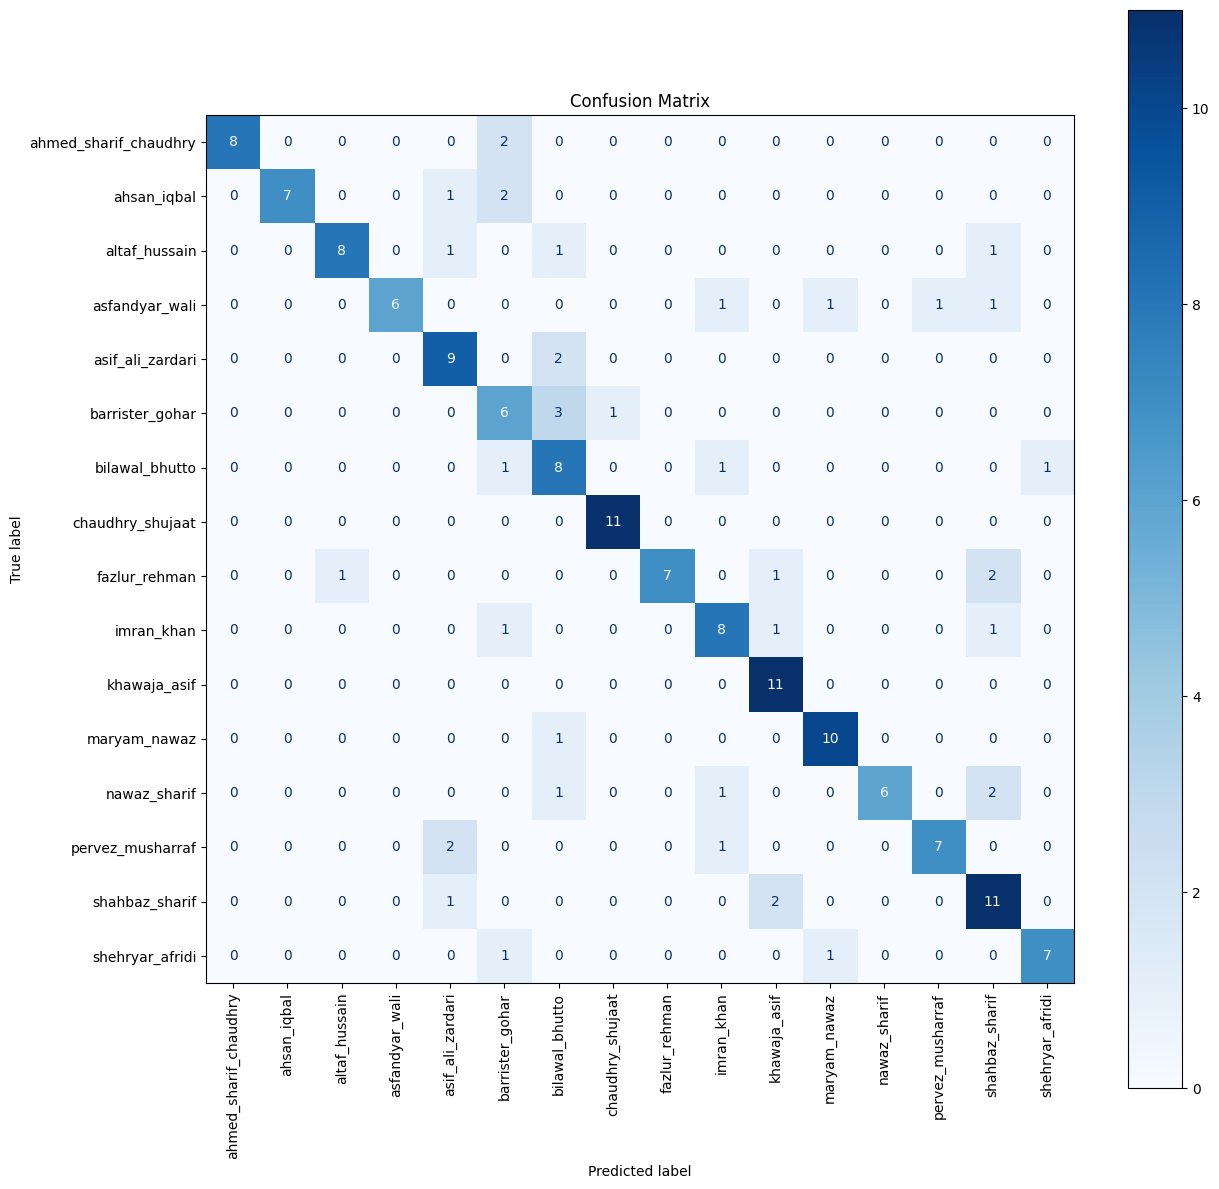

In [24]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Create Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
fig, ax = plt.subplots(figsize=(14,14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(
    xticks_rotation=90,
    cmap='Blues',
    ax=ax
)

plt.title("Confusion Matrix")

plt.show()

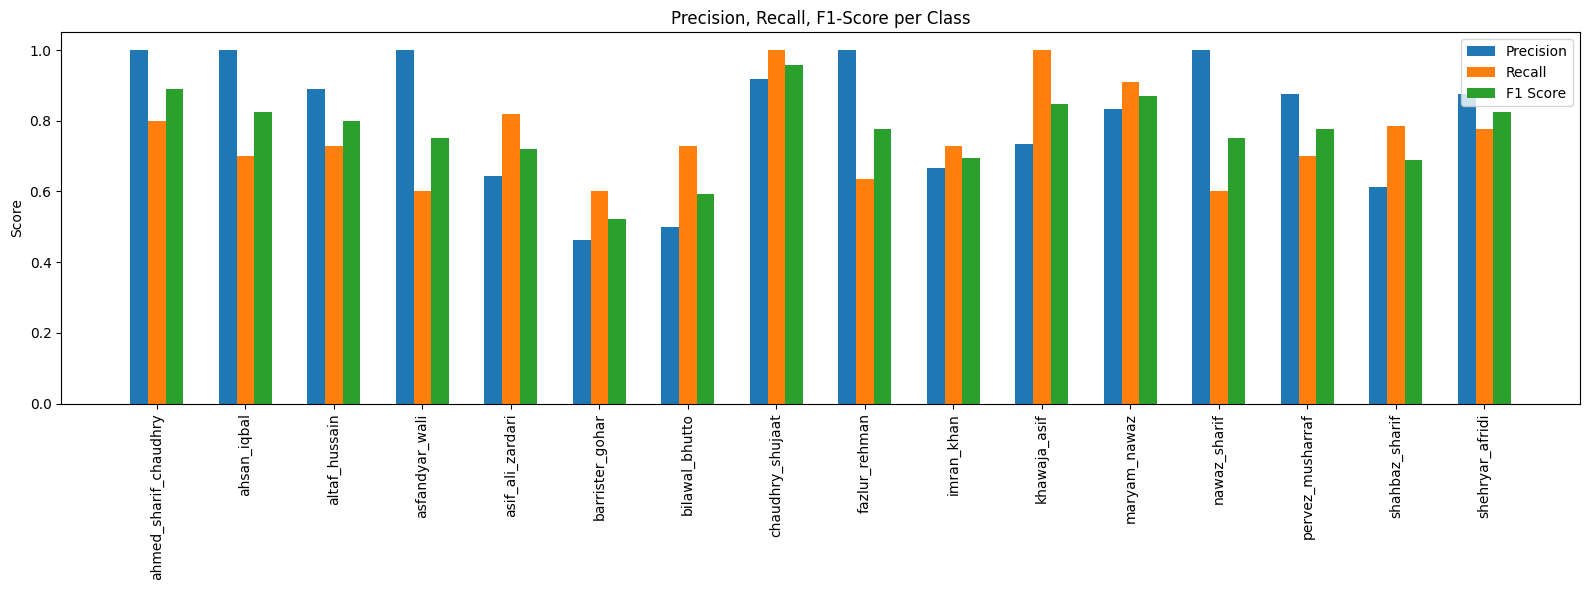

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_fscore_support

# Metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds
)

classes = train_dataset.classes

x = np.arange(len(classes))

plt.figure(figsize=(16,6))

plt.bar(x - 0.2, precision, width=0.2, label='Precision')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x + 0.2, f1, width=0.2, label='F1 Score')

plt.xticks(x, classes, rotation=90)

plt.ylabel("Score")

plt.title("Precision, Recall, F1-Score per Class")

plt.legend()

plt.tight_layout()

plt.show()

In [26]:
plt.savefig("/content/confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [21]:
# ──────────────────────────────────────────────────────────────────────────
# Save Model in .pth Format
# ──────────────────────────────────────────────────────────────────────────

torch.save(
    model.state_dict(),
    "/content/resnet50_weights.pth"
)

print(".pth file saved!")

# ──────────────────────────────────────────────────────────────────────────
# Save Complete Model in .pt Format
# ──────────────────────────────────────────────────────────────────────────

torch.save(
    model,
    "/content/resnet50_model.pt"
)

print(".pt file saved!")

# ──────────────────────────────────────────────────────────────────────────
# Save Weights in .tensor Format
# ──────────────────────────────────────────────────────────────────────────

torch.save(
    model.state_dict(),
    "/content/resnet50_weights.tensor"
)

print(".tensor file saved!")

.pth file saved!
.pt file saved!
.tensor file saved!


In [22]:
from google.colab import files

files.download("/content/resnet50_weights.pth")

files.download("/content/resnet50_model.pt")

files.download("/content/resnet50_weights.tensor")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [27]:
# ── BEST MODEL: EfficientNet-B4 Training on Google Colab ─────────────────

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report
from PIL import Image

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ── UPDATED DATASET PATH ──────────────────────────────────────────────────
DATA_DIR = "/content/dataset"

train_dir = f"{DATA_DIR}/train"
val_dir   = f"{DATA_DIR}/val"
test_dir  = f"{DATA_DIR}/test"

# ── Custom Loader for JFIF Support ────────────────────────────────────────
def pil_loader(path):

    with open(path, 'rb') as f:

        img = Image.open(f)

        return img.convert('RGB')

# ── Supported Extensions ──────────────────────────────────────────────────
IMG_EXTENSIONS = (
    '.jpg',
    '.jpeg',
    '.png',
    '.bmp',
    '.jfif'
)

# ── Strong Data Augmentation ──────────────────────────────────────────────
train_transform = transforms.Compose([

    transforms.RandomResizedCrop(380),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1)
    ),

    transforms.RandomPerspective(
        distortion_scale=0.2,
        p=0.3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ── Validation/Test Transform ─────────────────────────────────────────────
val_test_transform = transforms.Compose([

    transforms.Resize((380, 380)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ── Datasets ──────────────────────────────────────────────────────────────
train_dataset = ImageFolder(
    train_dir,
    transform=train_transform,
    loader=pil_loader,
    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

val_dataset = ImageFolder(
    val_dir,
    transform=val_test_transform,
    loader=pil_loader,
    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

test_dataset = ImageFolder(
    test_dir,
    transform=val_test_transform,
    loader=pil_loader,
    is_valid_file=lambda x: x.lower().endswith(IMG_EXTENSIONS)
)

# ── DataLoaders ───────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("Train Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Test Images:", len(test_dataset))

print("\nClasses:\n")
print(train_dataset.classes)

# ── Load EfficientNetB4 ───────────────────────────────────────────────────
model = models.efficientnet_b4(weights="IMAGENET1K_V1")

# ── Transfer Learning (Freeze Early Layers) ──────────────────────────────
for param in model.features[:5].parameters():

    param.requires_grad = False

# ── Replace Final Layer ───────────────────────────────────────────────────
num_classes = len(train_dataset.classes)

model.classifier[1] = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(
        model.classifier[1].in_features,
        num_classes
    )
)

# ── Move Model to GPU ─────────────────────────────────────────────────────
model = model.to(device)

# ── Loss Function ─────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

# ── Optimizer ─────────────────────────────────────────────────────────────
optimizer = optim.AdamW(

    filter(lambda p: p.requires_grad, model.parameters()),

    lr=0.0001,

    weight_decay=1e-4
)

# ── Scheduler ─────────────────────────────────────────────────────────────
scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode='min',

    factor=0.5,

    patience=3
)

# ── Early Stopping ────────────────────────────────────────────────────────
best_val_acc = 0.0

patience = 5

counter = 0

# ── Training ──────────────────────────────────────────────────────────────
num_epochs = 30

for epoch in range(num_epochs):

    # ── Training ───────────────────────
    model.train()

    train_loss = 0.0

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (predicted == labels).sum().item()

    train_acc = train_correct / train_total

    train_loss = train_loss / len(train_loader)

    # ── Validation ─────────────────────
    model.eval()

    val_loss = 0.0

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total

    val_loss = val_loss / len(val_loader)

    scheduler.step(val_loss)

    # ── Save Best Model ─────────────────
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        counter = 0

        torch.save(
            model.state_dict(),
            "/content/best_efficientnet_b4.pth"
        )

    else:

        counter += 1

    # ── Print Results ──────────────────
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    print(f"Train Loss          : {train_loss:.4f}")
    print(f"Train Accuracy      : {train_acc:.4f}")

    print(f"Validation Loss     : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")

    # ── Early Stopping ─────────────────
    if counter >= patience:

        print("\nEarly Stopping Triggered!")

        break

# ── Load Best Model ───────────────────────────────────────────────────────
model.load_state_dict(
    torch.load("/content/best_efficientnet_b4.pth")
)

# ── Final Testing ─────────────────────────────────────────────────────────
model.eval()

all_preds = []
all_labels = []

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

# ── Final Accuracy ────────────────────────────────────────────────────────
test_acc = test_correct / test_total

print("\n===================================")
print(f"FINAL TEST ACCURACY : {test_acc:.4f}")
print("===================================")

# ── Classification Report ─────────────────────────────────────────────────
print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

Using Device: cuda
Train Images: 1181
Validation Images: 231
Test Images: 171

Classes:

['ahmed_sharif_chaudhry', 'ahsan_iqbal', 'altaf_hussain', 'asfandyar_wali', 'asif_ali_zardari', 'barrister_gohar', 'bilawal_bhutto', 'chaudhry_shujaat', 'fazlur_rehman', 'imran_khan', 'khawaja_asif', 'maryam_nawaz', 'nawaz_sharif', 'pervez_musharraf', 'shahbaz_sharif', 'shehryar_afridi']
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 178MB/s]



Epoch [1/30]
Train Loss          : 2.7631
Train Accuracy      : 0.0787
Validation Loss     : 2.7440
Validation Accuracy : 0.1126

Epoch [2/30]
Train Loss          : 2.7282
Train Accuracy      : 0.1456
Validation Loss     : 2.7009
Validation Accuracy : 0.2771

Epoch [3/30]
Train Loss          : 2.6639
Train Accuracy      : 0.2024
Validation Loss     : 2.5913
Validation Accuracy : 0.3203

Epoch [4/30]
Train Loss          : 2.5047
Train Accuracy      : 0.2743
Validation Loss     : 2.3389
Validation Accuracy : 0.4069

Epoch [5/30]
Train Loss          : 2.2155
Train Accuracy      : 0.3294
Validation Loss     : 1.9086
Validation Accuracy : 0.4978

Epoch [6/30]
Train Loss          : 2.0033
Train Accuracy      : 0.3844
Validation Loss     : 1.5698
Validation Accuracy : 0.5974

Epoch [7/30]
Train Loss          : 1.8315
Train Accuracy      : 0.4361
Validation Loss     : 1.3661
Validation Accuracy : 0.6407

Epoch [8/30]
Train Loss          : 1.6225
Train Accuracy      : 0.5064
Validation Loss   

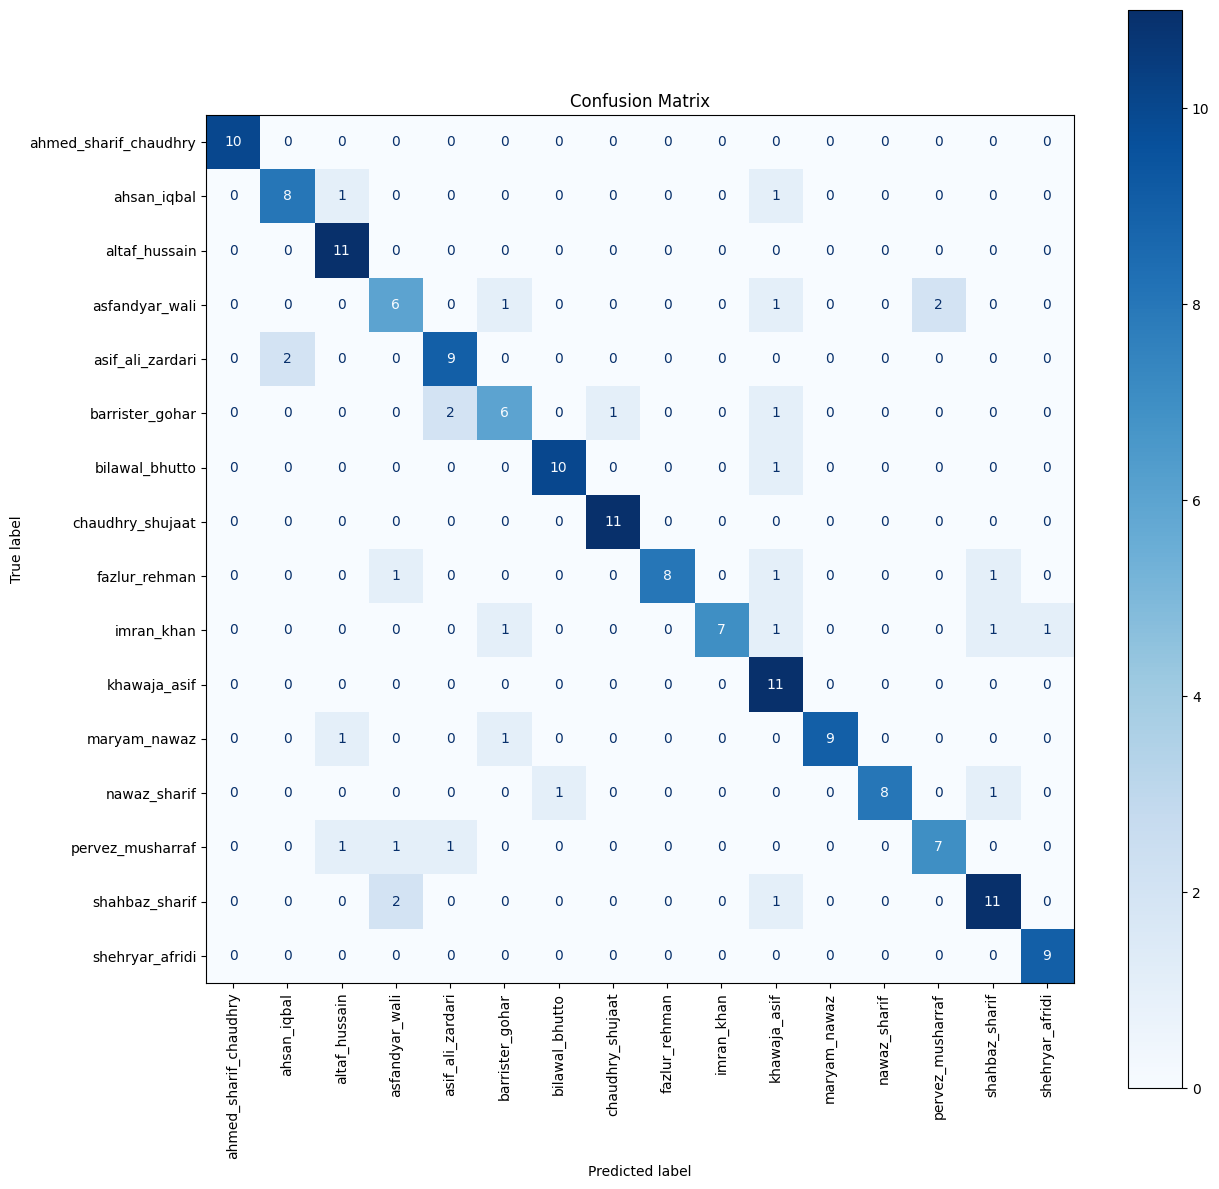

In [30]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Create Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
fig, ax = plt.subplots(figsize=(14,14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(
    xticks_rotation=90,
    cmap='Blues',
    ax=ax
)

plt.title("Confusion Matrix")

plt.show()

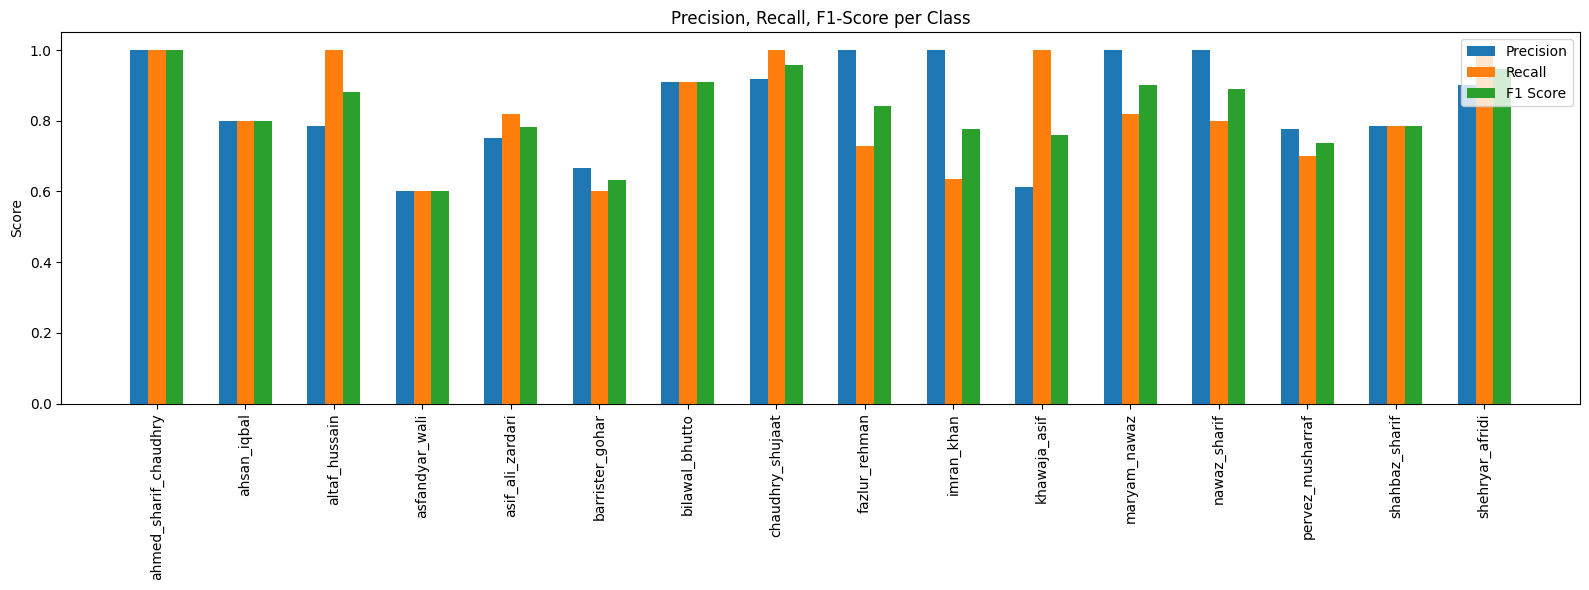

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_fscore_support

# Metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds
)

classes = train_dataset.classes

x = np.arange(len(classes))

plt.figure(figsize=(16,6))

plt.bar(x - 0.2, precision, width=0.2, label='Precision')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x + 0.2, f1, width=0.2, label='F1 Score')

plt.xticks(x, classes, rotation=90)

plt.ylabel("Score")

plt.title("Precision, Recall, F1-Score per Class")

plt.legend()

plt.tight_layout()

plt.show()

In [32]:
# ──────────────────────────────────────────────────────────────────────────
# Save Model in .pth Format
# ──────────────────────────────────────────────────────────────────────────

torch.save(
    model.state_dict(),
    "/content/resnet50_weights.pth"
)

print(".pth file saved!")

# ──────────────────────────────────────────────────────────────────────────
# Save Complete Model in .pt Format
# ──────────────────────────────────────────────────────────────────────────

torch.save(
    model,
    "/content/resnet50_model.pt"
)

print(".pt file saved!")

# ──────────────────────────────────────────────────────────────────────────
# Save Weights in .tensor Format
# ──────────────────────────────────────────────────────────────────────────

torch.save(
    model.state_dict(),
    "/content/resnet50_weights.tensor"
)

print(".tensor file saved!")

.pth file saved!
.pt file saved!
.tensor file saved!


In [33]:
from google.colab import files

files.download("/content/resnet50_weights.pth")

files.download("/content/resnet50_model.pt")

files.download("/content/resnet50_weights.tensor")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>